In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib.patches import Rectangle
from pathlib import Path
from typing import List, Union
from scipy.linalg import solve_triangular, qr
plt.style.use(hep.style.CMS)

In [2]:

def read_bootstrap_file(path: Union[str, Path], prefix: str) -> pd.DataFrame:
    """
    Read one bootstrap text file.
    - Drops the first 4 header lines.
    - Drops first data column (replica index).
    - Returns only bin columns, prefixed to keep names unique across files.
    """
    path = Path(path)

    # Header in these files starts with '#'; this also skips the first 4 lines
    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None)

    # Drop first row (text labels) and first column (replica/bin label)
    df = df.iloc[:, 1:].copy()
    df.columns = [f"{prefix}_bin{i}" for i in range(df.shape[1])]

    return df


def build_df(
    pth_path: Union[str, Path],
    nj_path: Union[str, Path],
    ptj0_path: Union[str, Path],
) -> pd.DataFrame:
    """Read all three files and return one dataframe per variable"""
    pth = read_bootstrap_file(pth_path, "pth")
    nj = read_bootstrap_file(nj_path, "nj")
    ptj0 = read_bootstrap_file(ptj0_path, "ptj0")

    # Check if all variables have the same number of replicas
    if not (len(pth) == len(nj) == len(ptj0)):
        raise ValueError("Replica counts do not match across files.")

    return pd.concat([pth, nj, ptj0], axis=1)

In [3]:
VARIABLE_PREFIXES = ("pth_", "nj_", "ptj0_")

CAT = ["cat0", "cat1", "cat2"]

def zero_intra_variable_off_diagonal_block(matrix: pd.DataFrame) -> pd.DataFrame:
    out = matrix.copy()
    cols = list(out.columns)
    for pref in VARIABLE_PREFIXES:
        group = [c for c in cols if c.startswith(pref)]
        for ci in group:
            for cj in group:
                if ci != cj:
                    out.loc[ci, cj] = 0.0
    return out


def corr_from_cov(cov_mat: pd.DataFrame) -> pd.DataFrame:
    v = np.diag(cov_mat.to_numpy())
    sigma = np.sqrt(np.clip(v, 0.0, None))
    with np.errstate(divide="ignore", invalid="ignore"):
        outer = np.outer(1.0 / sigma, 1.0 / sigma)
        arr = outer * cov_mat.to_numpy()
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(arr, 1.0)
    return pd.DataFrame(arr, index=cov_mat.index, columns=cov_mat.columns)

####################################################################################################

cov = {}
corr = {}
for cat in CAT:
    df = build_df(
        f"bootstrap/bootstrap_sideband_counts_pth_{cat}.txt",
        f"bootstrap/bootstrap_sideband_counts_nj_{cat}.txt",
        f"bootstrap/bootstrap_sideband_counts_ptj0_{cat}.txt",
    )
    c = df.cov()
    ## To force setting all off-diagonal entries within each observable to zero uncomment below
    ## This can be useful when running on few replicas where fluctuations can induce non-zero off-diagonal entries
    # c = zero_intra_variable_off_diagonal_block(c)
    cov[cat] = c
    corr[cat] = df.corr()

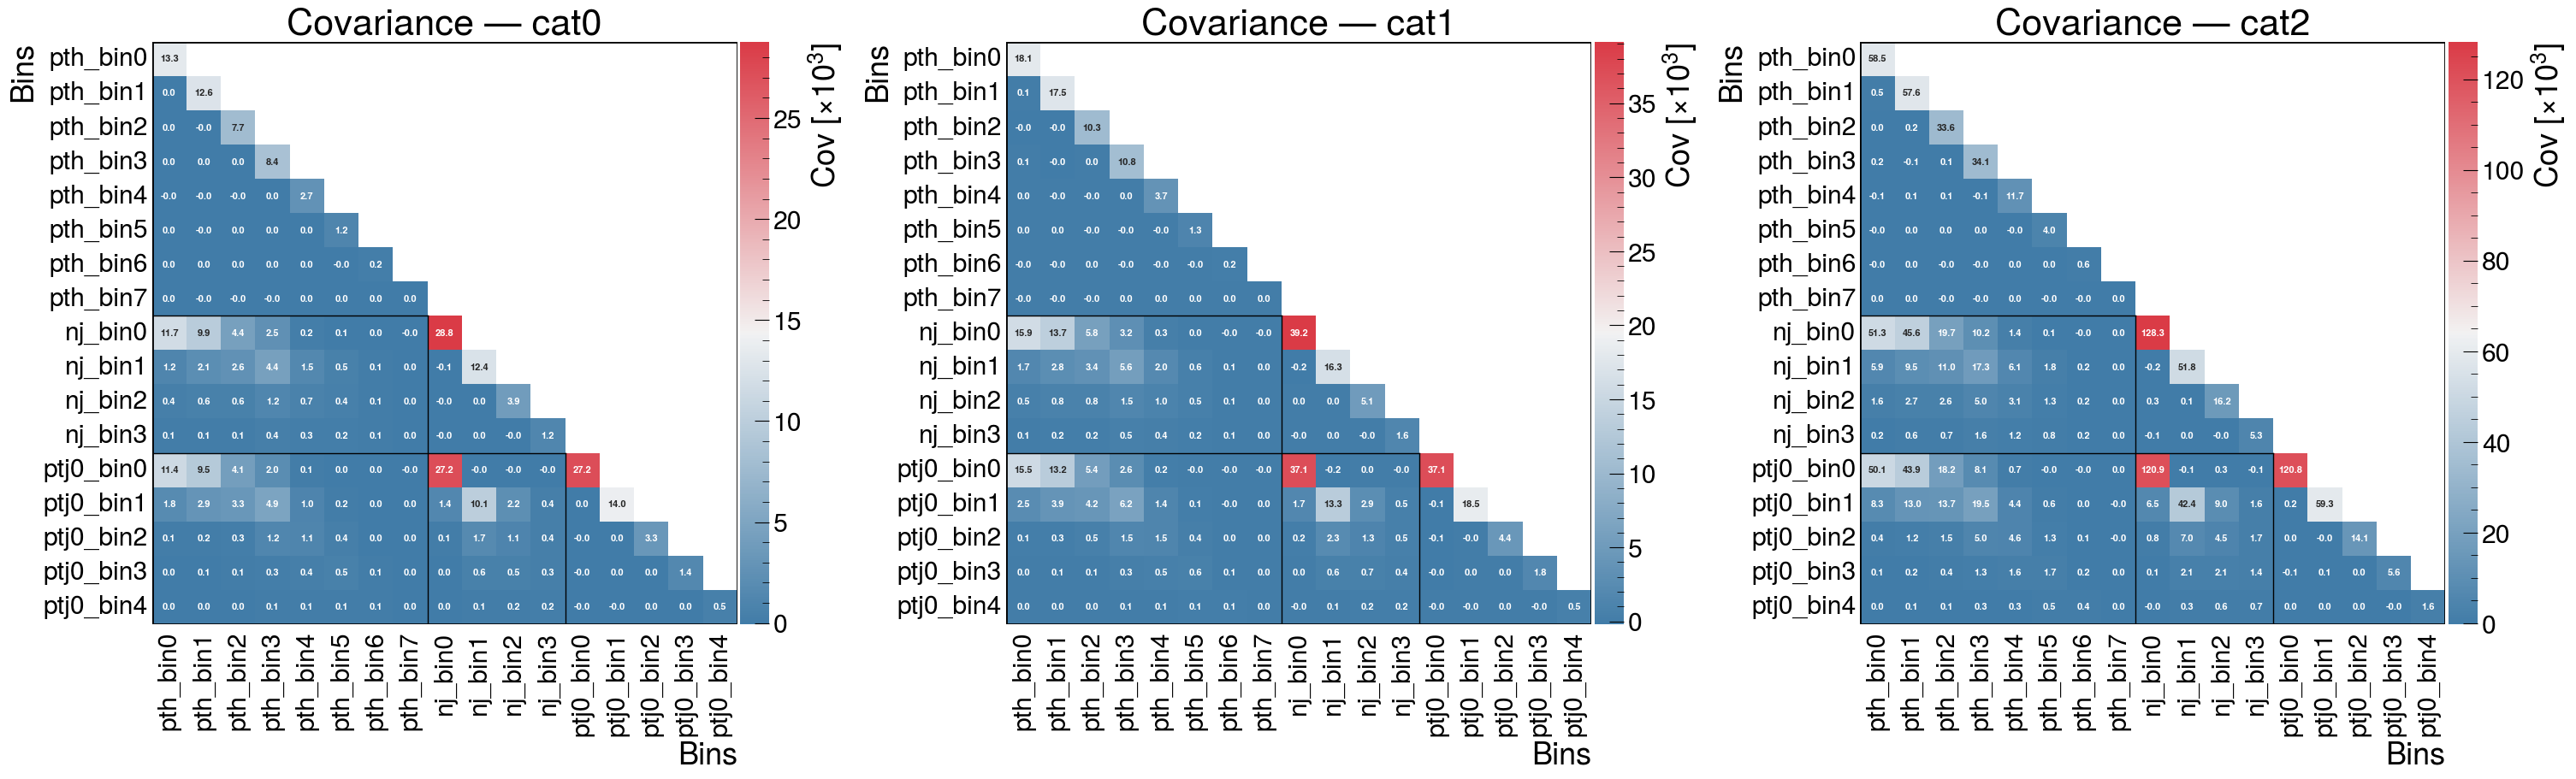

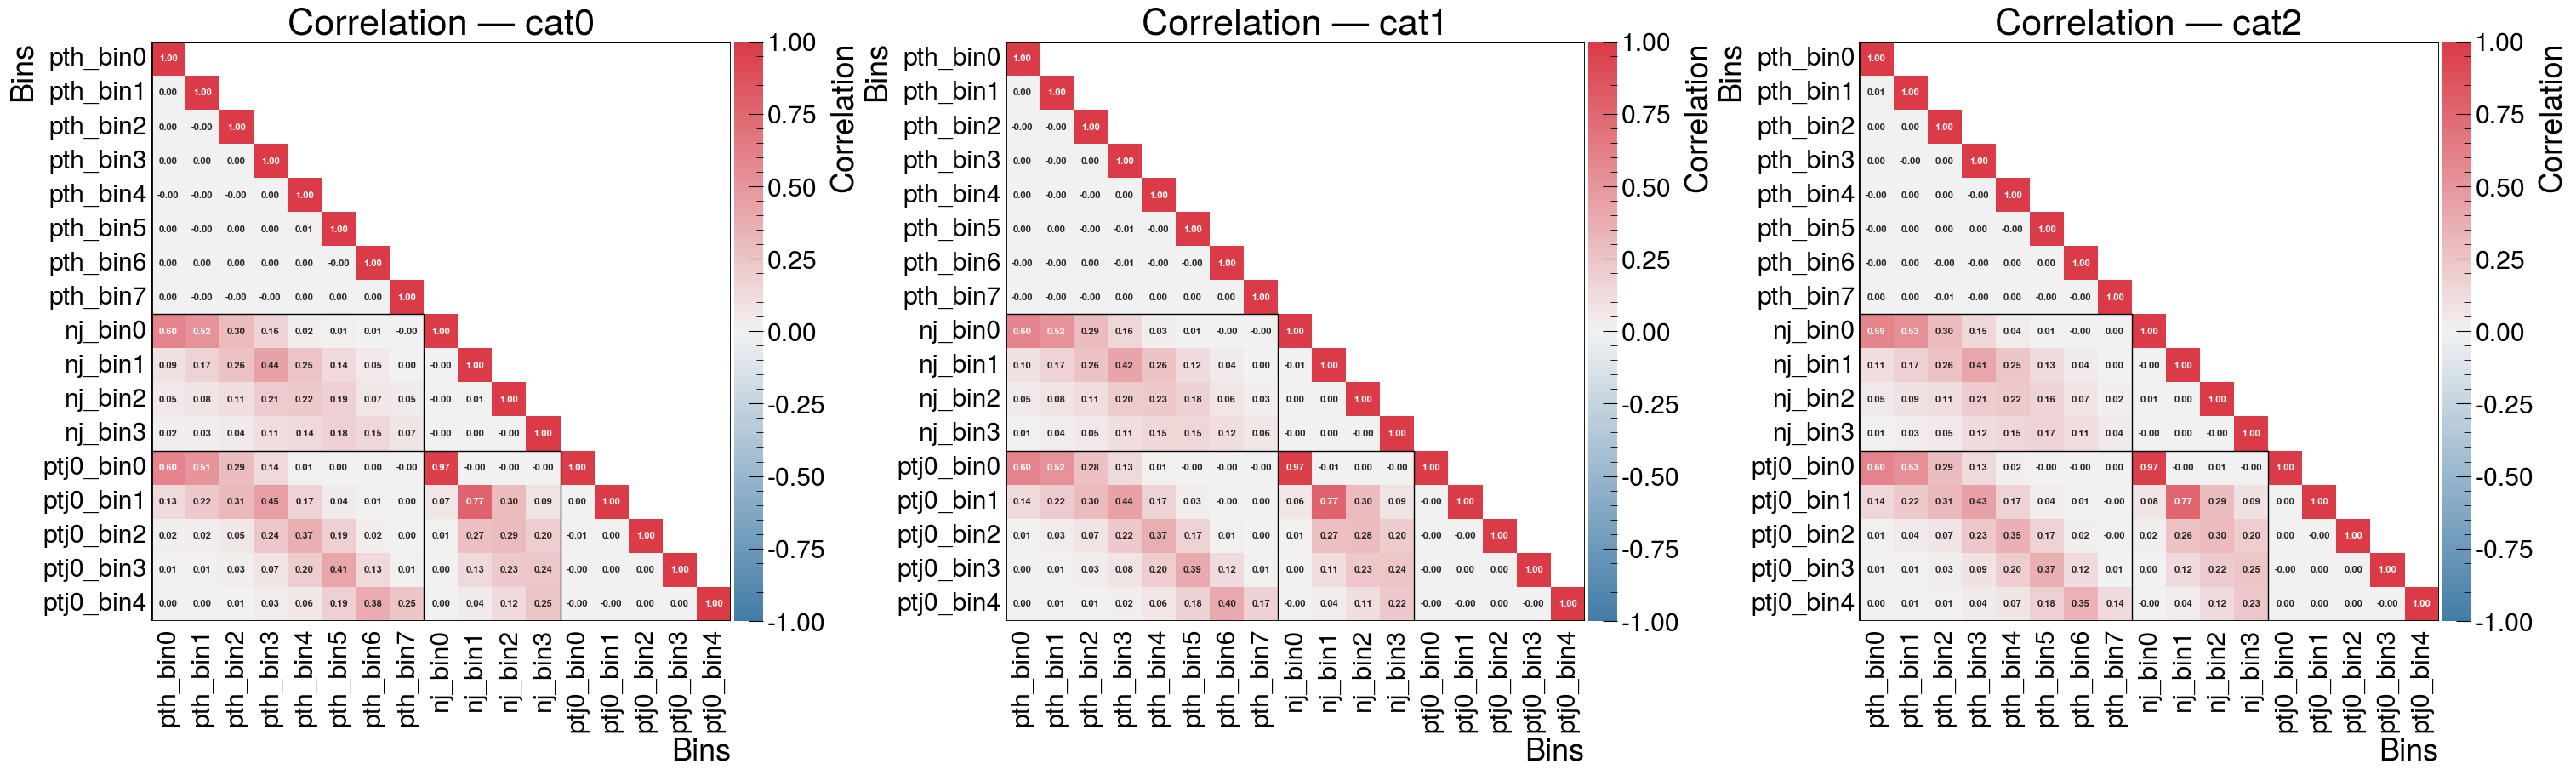

In [4]:
hep.style.use("CMS")
palette = sns.diverging_palette(240, 10, n=20, as_cmap=True)

# Boundaries between variable blocks (pth | nj | ptj0); same layout for all categories
_ref = cov[CAT[0]]  # same bin layout for all categories

b1 = len([c for c in _ref.columns if c.startswith("pth_")])
b2 = b1 + len([c for c in _ref.columns if c.startswith("nj_")])


def _decorate_matrix_ax(ax, n_bins: int) -> None:
    ax.tick_params(axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0)
    ax.tick_params(axis="y", which="both", labelrotation=0, left=False, right=False, length=0)
    ax.minorticks_off()
    for b in (b1, b2):
        ax.plot([0, b], [b, b], color="black", lw=1)
        ax.plot([b, b], [b, n_bins], color="black", lw=1)
    ax.add_patch(Rectangle((0, 0), n_bins, n_bins, fill=False, edgecolor="black", lw=2))


# 1) Covariance matrices (one panel per category)
cov_scale = 1e3
nc = len(CAT)
fig_cov, axes_cov = plt.subplots(1, nc, figsize=(10 * nc, 9), constrained_layout=True)
if nc == 1:
    axes_cov = np.array([axes_cov])

for ax, cat in zip(axes_cov.flat, CAT):
    cov_plot = cov[cat] / cov_scale
    cov_mask = np.triu(np.ones_like(cov_plot, dtype=bool), k=1)
    sns.heatmap(
        cov_plot,
        ax=ax,
        cmap=palette,
        mask=cov_mask,
        annot=True,
        fmt=".1f",
        # square=True,
        annot_kws={"size": 8, "weight": "bold"},
        cbar_kws={"label": r"Cov [$\times 10^3$]", 'pad': .005},
    )
    ax.set_title(f"Covariance — {cat}")
    ax.set_xlabel("Bins")
    ax.set_ylabel("Bins")
    _decorate_matrix_ax(ax, cov_plot.shape[0])

plt.show()

# 2) Correlation matrices (one panel per category)
fig_corr, axes_corr = plt.subplots(1, nc, figsize=(10 * nc, 9), constrained_layout=True)
if nc == 1:
    axes_corr = np.array([axes_corr])

for ax, cat in zip(axes_corr.flat, CAT):
    cmat = corr[cat]
    corr_mask = np.triu(np.ones_like(cmat, dtype=bool), k=1)
    sns.heatmap(
        cmat,
        ax=ax,
        cmap=palette,
        mask=corr_mask,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        center=0,
        square=True,
        annot_kws={"size": 8, "weight": "bold"},
        cbar_kws={"label": "Correlation", 'pad': .005},
    )
    ax.set_title(f"Correlation — {cat}")
    ax.set_xlabel("Bins")
    ax.set_ylabel("Bins")
    _decorate_matrix_ax(ax, cmat.shape[0])

plt.show()

In [7]:
## Loading the response matrix
def read_response_block(path: str):
    """Read response_matrix_*.txt and return numeric square block."""
    raw = pd.read_csv(path, sep=r"\s+", header=None)
    block = raw.iloc[1:, 1:].astype(float).to_numpy()
    if block.shape[0] != block.shape[1]:
        raise ValueError(f"Response block is not square for {path}: {block.shape}")
    return block


def response_paths_for_category(cat: str) -> dict:
    """Lumi-weighted response .txt paths per observable for one reco category."""
    return {
        "ptj0": f"response_matrix/response_matrix_ptJ0_{cat}.txt",
        "nj": f"response_matrix/response_matrix_Njets2p5_{cat}.txt",
        "pth": f"response_matrix/response_matrix_pth_{cat}.txt",
    }


def build_block_diagonal_resp(cov_mat: pd.DataFrame, cat: str) -> pd.DataFrame:
    resp_files = response_paths_for_category(cat)
    cols = list(cov_mat.columns)
    prefix_order = []
    for col in cols:
        pref = col.split("_", 1)[0]
        if pref not in prefix_order:
            prefix_order.append(pref)

    resp = pd.DataFrame(0.0, index=cov_mat.index, columns=cov_mat.columns)
    start = 0
    for pref in prefix_order:
        block_cols = [c for c in cols if c.startswith(f"{pref}_")]
        n = len(block_cols)
        if pref not in resp_files:
            raise ValueError(f"No response matrix file configured for prefix '{pref}'")

        block = read_response_block(resp_files[pref])
        if block.shape != (n, n):
            raise ValueError(
                f"Shape mismatch for {resp_files[pref]}: got {block.shape}, expected {(n, n)}"
            )

        stop = start + n
        resp.iloc[start:stop, start:stop] = block
        start = stop
    return resp


# One block-diagonal R per reco category (same layout as cov[cat])
resp = {cat: build_block_diagonal_resp(cov[cat], cat) for cat in CAT}


In [22]:
## Helper function to invert a matrix and compute correlations from covariances
def invert_matrix(matrix: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        np.linalg.inv(matrix.to_numpy()),
        index=matrix.index,
        columns=matrix.columns,
    )

## Helper function to compute correlations from covariances
def compute_corr(cov: pd.DataFrame) -> pd.DataFrame:
    sigma = np.sqrt(np.diag(cov.to_numpy()))
    denom = np.outer(sigma, sigma)
    corr = np.divide(
        cov.to_numpy(),
        denom,
        out=np.zeros_like(cov.to_numpy()), 
        where=denom != 0,
    )
    return pd.DataFrame(corr, index=cov.index, columns=cov.columns)

## Helper function to regularize a matrix
def regularize_spd(cov_df: pd.DataFrame, rel_floor: float = 1e-10) -> pd.DataFrame:
    # a is forced to be exactly symmetric (numerically, covariance estimates can be slightly non-symmetric)
    # The elements of A+A^T are the sum of the corresponding entries of A 
    a = 0.5 * (cov_df.to_numpy() + cov_df.to_numpy().T)
    # Eigen-decomposition of the symmetric matrix a
    # w -> eigenvalues; v -> eigenvectors
    w, v = np.linalg.eigh(a)
    lam_max = np.max(np.abs(w)) if w.size else 1.0
    floor = rel_floor * max(lam_max, 1.0)
    w_reg = np.clip(w, floor, None)
    a_reg = (v * w_reg) @ v.T
    return pd.DataFrame(a_reg, index=cov_df.index, columns=cov_df.columns)

In [23]:
fisher_cat = {}

for cat in CAT:
    r = resp[cat]
    fisher_cat[cat] = r.T @ invert_matrix(regularize_spd(cov[cat])) @ r # With regularization of the covariance matrix before inversion
    # fisher_cat[cat] = r.T @ invert_matrix(cov[cat]) @ r # With regularization of the covariance matrix before inversion

## Correlations per category
cov_gen_cat_0 = invert_matrix(fisher_cat["cat0"])
cov_gen_cat_1 = invert_matrix(fisher_cat["cat1"])
cov_gen_cat_2 = invert_matrix(fisher_cat["cat2"])
corr_gen_cat_0 = compute_corr(cov_gen_cat_0)
corr_gen_cat_1 = compute_corr(cov_gen_cat_1)
corr_gen_cat_2 = compute_corr(cov_gen_cat_2)

cov_gen = invert_matrix(fisher_cat["cat0"] + fisher_cat["cat1"] + fisher_cat["cat2"])
corr_gen = compute_corr(cov_gen)

In [24]:
# Plot correlation matrix at gen-level
def plot_corr(_corr_gen):
    corr_gen_mask = np.triu(np.ones_like(_corr_gen, dtype=bool), k=1)
    fig_corr_gen, ax_corr_gen = plt.subplots(figsize=(12, 10), constrained_layout=True)
    sns.heatmap(
        _corr_gen,
        ax=ax_corr_gen,
        cmap=palette,
        mask=corr_gen_mask,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        center=0,
        square=True,
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"label": "Correlation"},
    )
    ax_corr_gen.set_title("Correlation Matrix (Generator Level)")
    ax_corr_gen.set_xlabel("Bins")
    ax_corr_gen.set_ylabel("Bins")
    ax_corr_gen.tick_params(axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0)
    ax_corr_gen.tick_params(axis="y", which="both", labelrotation=0, left=False, right=False, length=0)
    ax_corr_gen.minorticks_off()
    n_bins = corr_gen.shape[0]
    for b in (b1, b2):
        # Draw only on the visible lower triangle
        ax_corr_gen.plot([0, b], [b, b], color="black", lw=1)
        ax_corr_gen.plot([b, b], [b, n_bins], color="black", lw=1)
    ax_corr_gen.add_patch(Rectangle((0, 0), n_bins, n_bins, fill=False, edgecolor="black", lw=2))
    plt.show()

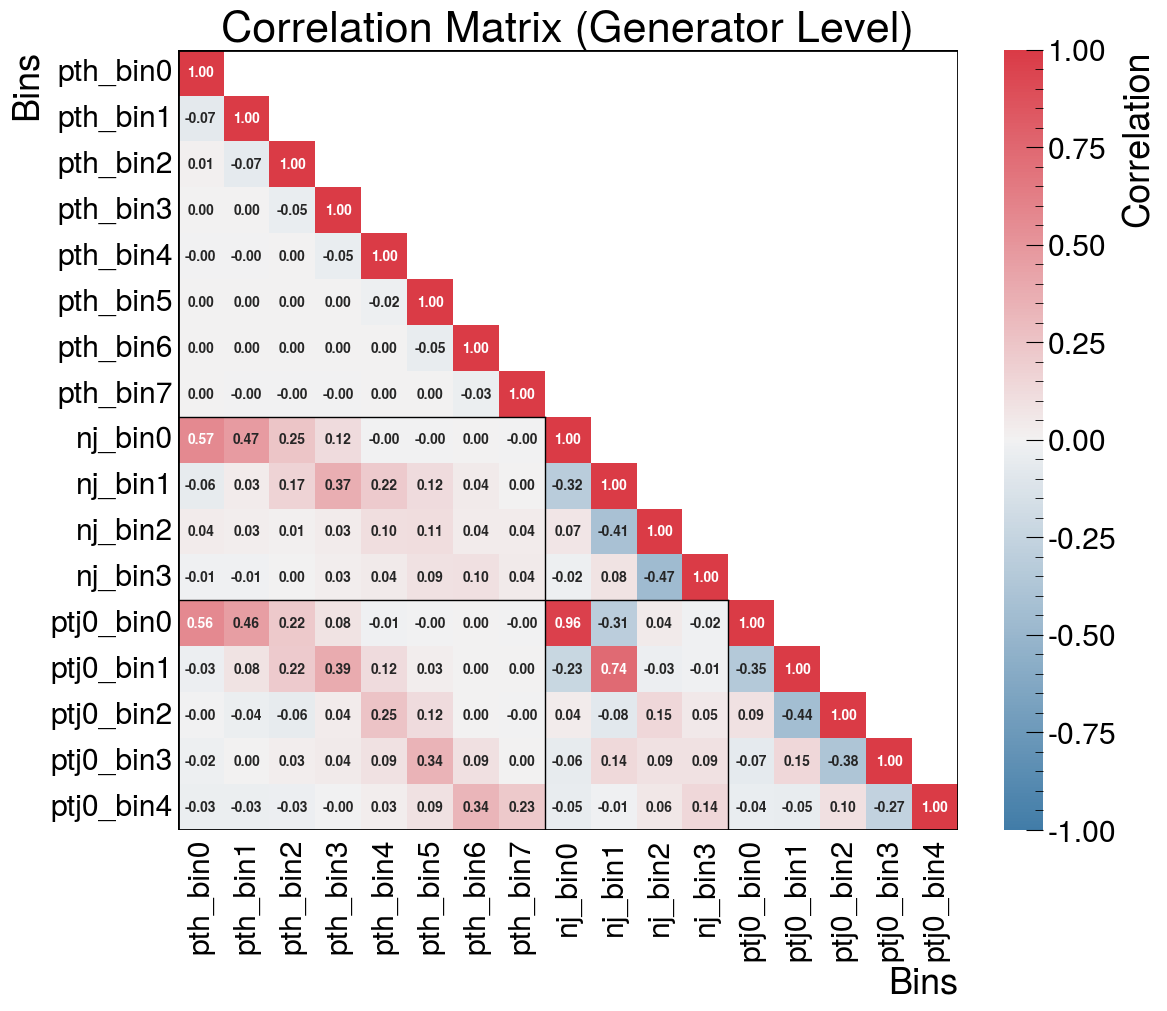

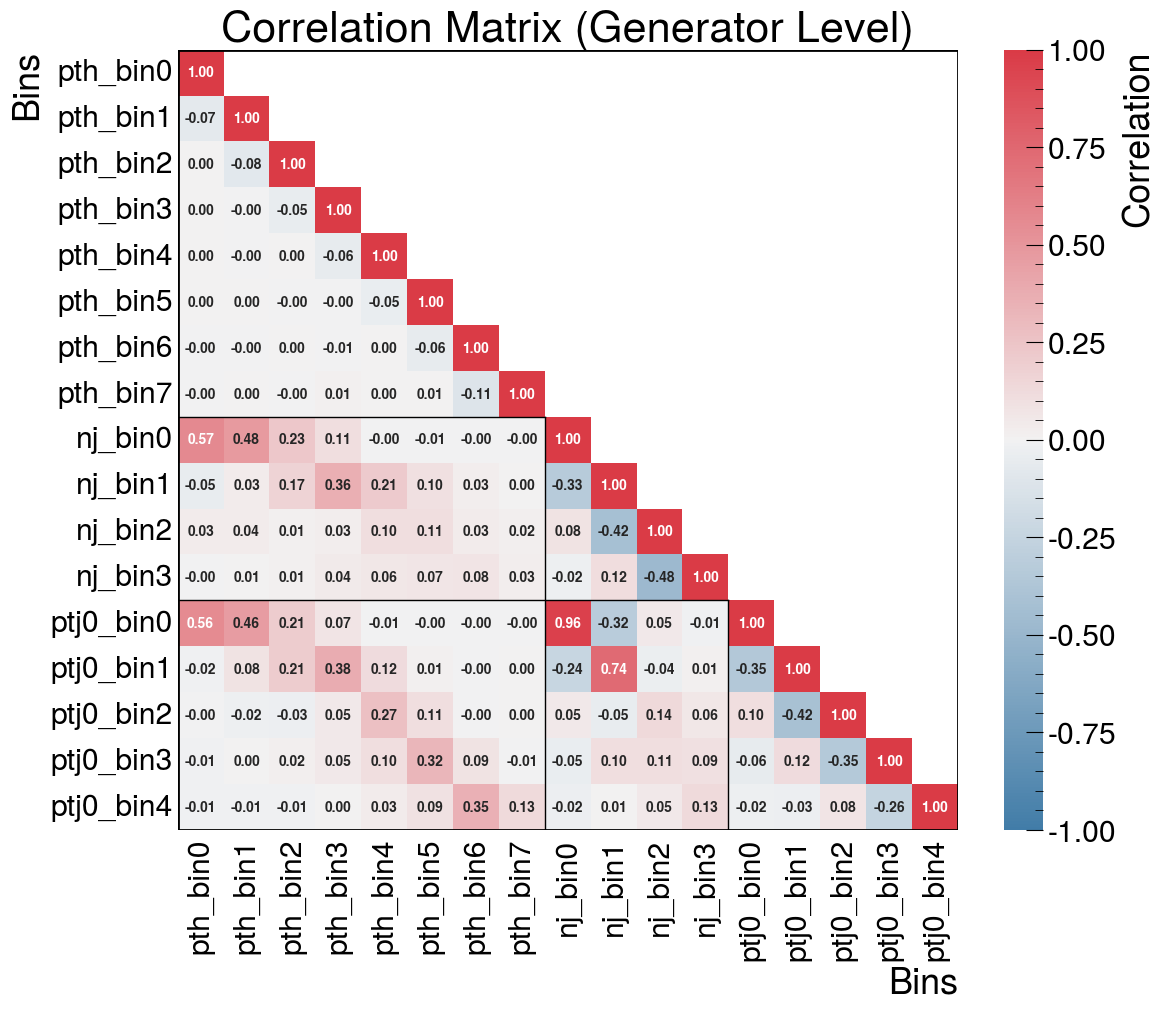

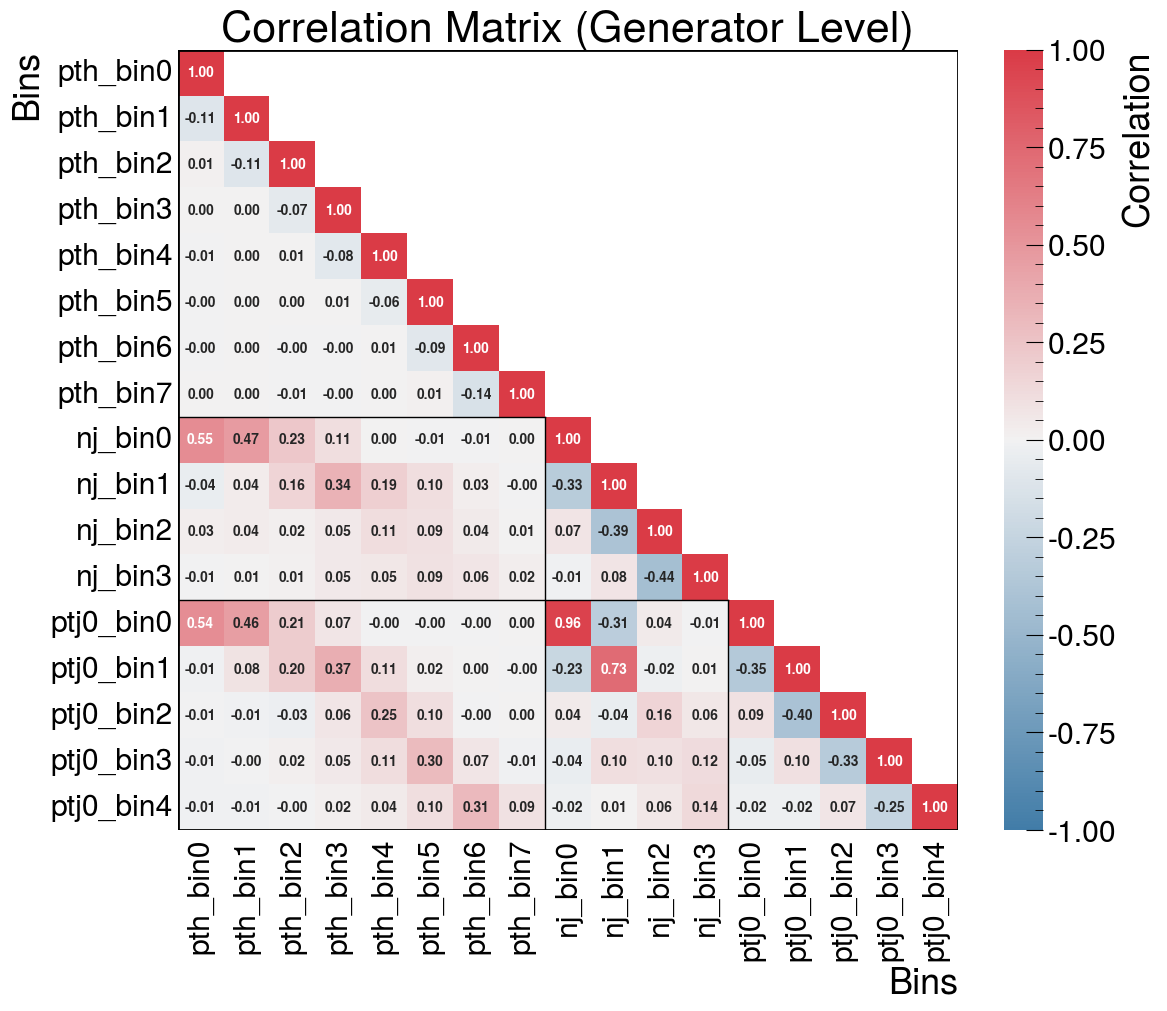

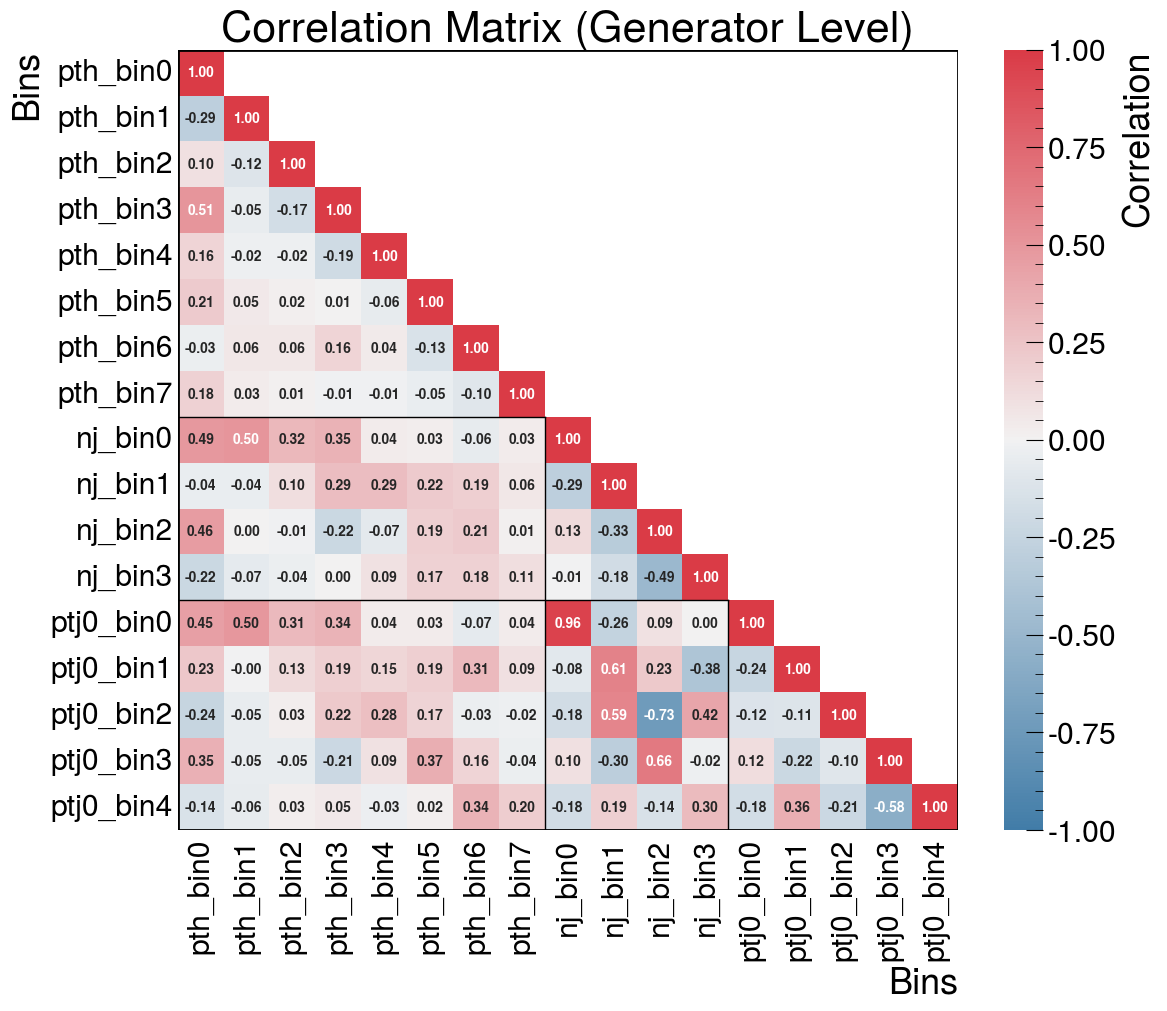

In [25]:
plot_corr(corr_gen_cat_0)
plot_corr(corr_gen_cat_1)
plot_corr(corr_gen_cat_2)

plot_corr(corr_gen)

Here below I try to compute the matrix with the Cholesky decomposition to avoid inversion of matrices

In [26]:
def compute_C_gen(R_list, C_list, bin_names=None, regularisation=1e-10):
    """
    Compute the gen-level statistical covariance and correlation matrices.

    Parameters
    ----------
    R_list         : list of K arrays, each (n_reco_k, n_gen)
    C_list         : list of K arrays, each (n_reco_k, n_reco_k)
    bin_names      : list of n_gen strings for row/column labels (optional)
    regularisation : float, diagonal loading factor (default 1e-10)

    Returns
    -------
    dict with keys:
        "covariance"   : pd.DataFrame (n_gen x n_gen)
        "correlation"  : pd.DataFrame (n_gen x n_gen)
    """

    R_tilde_list = []
    for k, (R_k, C_k) in enumerate(zip(R_list, C_list)):
        C_k     = (C_k + C_k.T) / 2.0
        epsilon = regularisation * np.trace(C_k)
        C_k_reg = C_k + epsilon * np.eye(C_k.shape[0])
        L_k     = np.linalg.cholesky(C_k_reg)
        R_tilde_list.append(solve_triangular(L_k, R_k, lower=True))

    R_tot   = np.vstack(R_tilde_list)
    _, R_QR = qr(R_tot, mode='economic')

    n_gen    = R_QR.shape[0]
    R_QR_inv = solve_triangular(R_QR, np.eye(n_gen), lower=False)
    C_gen    = R_QR_inv @ R_QR_inv.T

    std  = np.sqrt(np.diag(C_gen))
    corr = np.clip(C_gen / np.outer(std, std), -1.0, 1.0)

    # Build labels
    if bin_names is None:
        bin_names = [f"bin{i}" for i in range(n_gen)]

    return {
        "covariance"  : pd.DataFrame(C_gen, index=bin_names, columns=bin_names),
        "correlation" : pd.DataFrame(corr,  index=bin_names, columns=bin_names),
    }

In [29]:
cov_gen_cholesky = compute_C_gen(
    [resp["cat0"], resp["cat1"], resp["cat2"]],
    [cov["cat0"], cov["cat1"], cov["cat2"]],
    bin_names = cov["cat0"].index,
    regularisation=1e-10
)

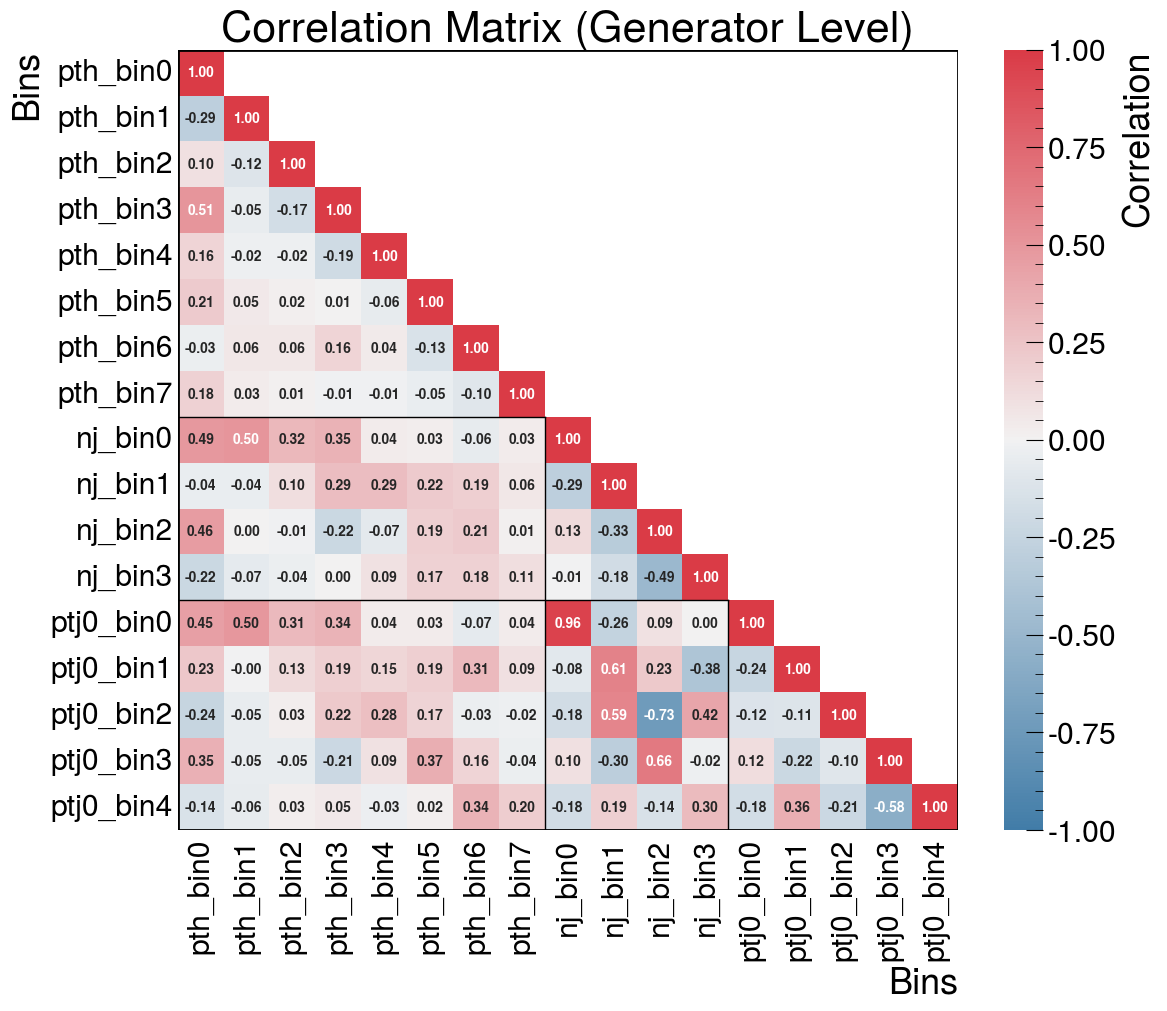

In [32]:
plot_corr(cov_gen_cholesky["correlation"])